In [1]:
import torch

print(torch.__version__)

print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))


2.5.1+cu121
True
NVIDIA GeForce RTX 4060 Laptop GPU


teacher_train.py

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
from torchvision.models import resnet18


# =========================================
# Device
# =========================================
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print(device)


# =========================================
# Transform
# 与 DeiT 输入一致
# =========================================
transform_train = transforms.Compose([

    transforms.Resize((96, 96)),

    transforms.RandomCrop(
        96,
        padding=12
    ),

    transforms.RandomHorizontalFlip(),

    transforms.ToTensor(),

    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

transform_test = transforms.Compose([

    transforms.Resize((96, 96)),

    transforms.ToTensor(),

    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])


# =========================================
# Dataset
# =========================================
trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=False,
    transform=transform_train
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=False,
    transform=transform_test
)

trainloader = DataLoader(
    trainset,
    batch_size=128,
    shuffle=True,
    num_workers=2
)

testloader = DataLoader(
    testset,
    batch_size=128,
    shuffle=False,
    num_workers=2
)


# =========================================
# Teacher Network
# =========================================
model = resnet18(weights=None)

model.fc = nn.Linear(
    model.fc.in_features,
    10
)

model = model.to(device)


# =========================================
# Loss
# =========================================
criterion = nn.CrossEntropyLoss()


# =========================================
# Optimizer
# =========================================
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=30
)


# =========================================
# Train
# =========================================
best_acc = 0

for epoch in range(30):

    model.train()

    running_loss = 0

    for images, labels in trainloader:

        images = images.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    scheduler.step()


    # =====================================
    # Evaluate
    # =====================================
    model.eval()

    correct = 0

    total = 0

    with torch.no_grad():

        for images, labels in testloader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    acc = 100. * correct / total

    print(
        f'Epoch [{epoch+1}/30] '
        f'Loss: {running_loss/len(trainloader):.4f} '
        f'Acc: {acc:.2f}%'
    )


    # =====================================
    # Save Best
    # =====================================
    if acc > best_acc:

        best_acc = acc

        torch.save(
            model.state_dict(),
            'teacher.pth'
        )

        print('Teacher Model Saved')


print(f'Best Accuracy: {best_acc:.2f}%')

cuda
Epoch [1/30] Loss: 1.4256 Acc: 59.57%
Teacher Model Saved
Epoch [2/30] Loss: 1.0070 Acc: 65.96%
Teacher Model Saved
Epoch [3/30] Loss: 0.8031 Acc: 72.48%
Teacher Model Saved
Epoch [4/30] Loss: 0.6761 Acc: 74.18%
Teacher Model Saved
Epoch [5/30] Loss: 0.5861 Acc: 78.27%
Teacher Model Saved
Epoch [6/30] Loss: 0.5237 Acc: 80.45%
Teacher Model Saved
Epoch [7/30] Loss: 0.4703 Acc: 82.07%
Teacher Model Saved
Epoch [8/30] Loss: 0.4277 Acc: 83.08%
Teacher Model Saved
Epoch [9/30] Loss: 0.3875 Acc: 84.46%
Teacher Model Saved
Epoch [10/30] Loss: 0.3568 Acc: 84.64%
Teacher Model Saved
Epoch [11/30] Loss: 0.3228 Acc: 86.24%
Teacher Model Saved
Epoch [12/30] Loss: 0.2942 Acc: 85.07%
Epoch [13/30] Loss: 0.2679 Acc: 85.83%
Epoch [14/30] Loss: 0.2451 Acc: 86.47%
Teacher Model Saved
Epoch [15/30] Loss: 0.2165 Acc: 87.65%
Teacher Model Saved
Epoch [16/30] Loss: 0.1934 Acc: 88.13%
Teacher Model Saved
Epoch [17/30] Loss: 0.1722 Acc: 87.86%
Epoch [18/30] Loss: 0.1541 Acc: 88.50%
Teacher Model Saved
Ep

train.py

cuda


C:\Users\hzghz\AppData\Local\Temp\ipykernel_5712\3794300507.py:114: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(
C:\Users\hzghz\AppData\Local\Temp\ipykernel_571

Epoch [1/100] Loss: 9.3742 Acc: 33.53%
Model Saved
Epoch [2/100] Loss: 8.4160 Acc: 36.50%
Model Saved
Epoch [3/100] Loss: 7.9497 Acc: 39.41%
Model Saved
Epoch [4/100] Loss: 7.5908 Acc: 45.06%
Model Saved
Epoch [5/100] Loss: 7.2286 Acc: 45.91%
Model Saved
Epoch [6/100] Loss: 7.0245 Acc: 47.89%
Model Saved
Epoch [7/100] Loss: 6.7736 Acc: 49.09%
Model Saved
Epoch [8/100] Loss: 6.5339 Acc: 52.19%
Model Saved
Epoch [9/100] Loss: 6.3346 Acc: 53.49%
Model Saved
Epoch [10/100] Loss: 6.1459 Acc: 54.92%
Model Saved
Epoch [11/100] Loss: 5.9870 Acc: 55.48%
Model Saved
Epoch [12/100] Loss: 5.8433 Acc: 59.08%
Model Saved
Epoch [13/100] Loss: 5.6661 Acc: 59.38%
Model Saved
Epoch [14/100] Loss: 5.4611 Acc: 62.81%
Model Saved
Epoch [15/100] Loss: 5.3029 Acc: 61.88%
Epoch [16/100] Loss: 5.1585 Acc: 63.79%
Model Saved
Epoch [17/100] Loss: 5.0125 Acc: 65.29%
Model Saved
Epoch [18/100] Loss: 4.9072 Acc: 66.99%
Model Saved
Epoch [19/100] Loss: 4.8004 Acc: 68.09%
Model Saved
Epoch [20/100] Loss: 4.6984 Acc: 

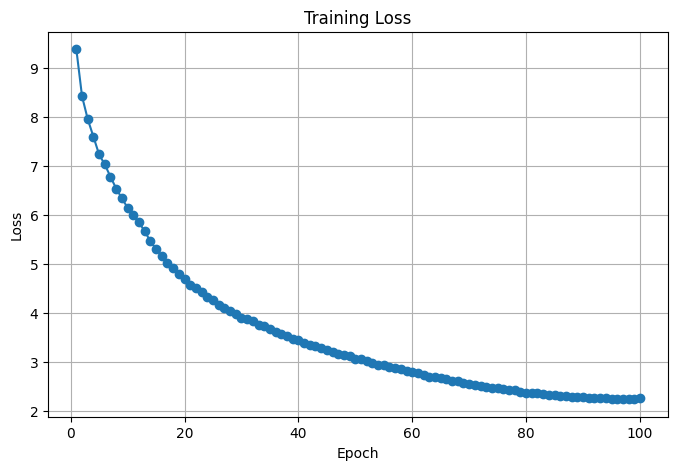

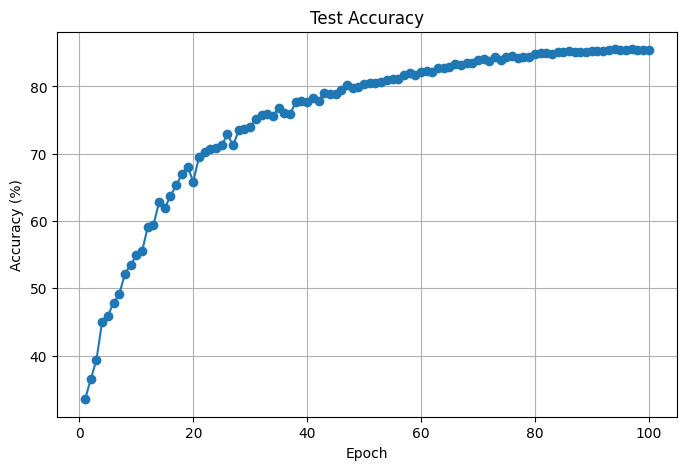

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import timm

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader


# =========================================
# Device
# =========================================
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print(device)


# =========================================
# Data Augmentation
# DeiT风格增强
# =========================================
transform_train = transforms.Compose([

    transforms.Resize((96, 96)),

    transforms.RandomCrop(
        96,
        padding=12
    ),

    transforms.RandomHorizontalFlip(),

    transforms.RandAugment(
        num_ops=2,
        magnitude=9
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010)
    ),

    transforms.RandomErasing(
        p=0.25
    )
])

transform_test = transforms.Compose([

    transforms.Resize((96, 96)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010)
    )
])


# =========================================
# Dataset
# =========================================
trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=False,
    transform=transform_train
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=False,
    transform=transform_test
)

trainloader = DataLoader(
    trainset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

testloader = DataLoader(
    testset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


# =========================================
# Teacher Network
# =========================================
from torchvision.models import resnet18

teacher = resnet18(weights=None)

teacher.fc = nn.Linear(
    teacher.fc.in_features,
    10
)

teacher.load_state_dict(
    torch.load(
        'teacher.pth',
        map_location=device
    )
)

teacher = teacher.to(device)

teacher.eval()


# =========================================
# DeiT Tiny Student
# =========================================
student = timm.create_model(
    'deit_tiny_distilled_patch16_224',
    pretrained=False,
    num_classes=10,
    img_size=96
)

student = student.to(device)


# =========================================
# Loss
# =========================================
ce_loss = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

kl_loss = nn.KLDivLoss(
    reduction='batchmean'
)


# =========================================
# Optimizer
# =========================================
optimizer = optim.AdamW(
    student.parameters(),
    lr=5e-4,
    weight_decay=0.05
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=100
)


# =========================================
# AMP
# =========================================
scaler = torch.cuda.amp.GradScaler()


# =========================================
# Distillation Parameters
# =========================================
alpha = 0.5
temperature = 4.0


# =========================================
# Record
# =========================================
train_losses = []

test_accs = []

best_acc = 0


# =========================================
# Train
# =========================================
for epoch in range(100):

    student.train()

    running_loss = 0

    for images, labels in trainloader:

        images = images.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        # =========================
        # Teacher Output
        # =========================
        with torch.no_grad():

            teacher_outputs = teacher(images)

        # =========================
        # Student Forward
        # =========================
        with torch.cuda.amp.autocast():

            student_outputs = student(images)

            # 分类损失
            loss_ce = ce_loss(
                student_outputs,
                labels
            )

            # 蒸馏损失
            loss_kd = kl_loss(

                torch.log_softmax(
                    student_outputs / temperature,
                    dim=1
                ),

                torch.softmax(
                    teacher_outputs / temperature,
                    dim=1
                )

            ) * (temperature ** 2)

            # 总损失
            loss = (
                alpha * loss_ce +
                (1 - alpha) * loss_kd
            )

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

    scheduler.step()


    # =====================================
    # Evaluate
    # =====================================
    student.eval()

    correct = 0

    total = 0

    with torch.no_grad():

        for images, labels in testloader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = student(images)

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    acc = 100.0 * correct / total

    epoch_loss = running_loss / len(trainloader)

    train_losses.append(epoch_loss)

    test_accs.append(acc)

    print(
        f'Epoch [{epoch+1}/100] '
        f'Loss: {epoch_loss:.4f} '
        f'Acc: {acc:.2f}%'
    )


    # =====================================
    # Save Best
    # =====================================
    if acc > best_acc:

        best_acc = acc

        torch.save(
            student.state_dict(),
            'best_deit_distill.pth'
        )

        print('Model Saved')


print(f'Best Accuracy: {best_acc:.2f}%')


# =========================================
# Draw Curves
# =========================================
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

# Loss
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    marker='o'
)

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title('Training Loss')

plt.grid(True)

plt.show()


# Accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    test_accs,
    marker='o'
)

plt.xlabel('Epoch')

plt.ylabel('Accuracy (%)')

plt.title('Test Accuracy')

plt.grid(True)

plt.show()

ViT

cuda


C:\Users\hzghz\AppData\Local\Temp\ipykernel_28004\3480579920.py:132: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
C:\Users\hzghz\AppData\Local\Temp\ipykernel_28004\3480579920.py:161: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [1/100] Loss: 2.0682 Acc: 33.29%
Model Saved
Epoch [2/100] Loss: 1.9292 Acc: 38.12%
Model Saved
Epoch [3/100] Loss: 1.8657 Acc: 41.30%
Model Saved
Epoch [4/100] Loss: 1.8170 Acc: 44.10%
Model Saved
Epoch [5/100] Loss: 1.7762 Acc: 44.97%
Model Saved
Epoch [6/100] Loss: 1.7440 Acc: 47.00%
Model Saved
Epoch [7/100] Loss: 1.7128 Acc: 50.75%
Model Saved
Epoch [8/100] Loss: 1.6783 Acc: 51.85%
Model Saved
Epoch [9/100] Loss: 1.6474 Acc: 51.30%
Epoch [10/100] Loss: 1.6172 Acc: 52.71%
Model Saved
Epoch [11/100] Loss: 1.5910 Acc: 54.76%
Model Saved
Epoch [12/100] Loss: 1.5698 Acc: 54.25%
Epoch [13/100] Loss: 1.5444 Acc: 55.90%
Model Saved
Epoch [14/100] Loss: 1.5202 Acc: 57.54%
Model Saved
Epoch [15/100] Loss: 1.4967 Acc: 60.06%
Model Saved
Epoch [16/100] Loss: 1.4695 Acc: 60.37%
Model Saved
Epoch [17/100] Loss: 1.4500 Acc: 61.88%
Model Saved
Epoch [18/100] Loss: 1.4283 Acc: 63.86%
Model Saved
Epoch [19/100] Loss: 1.4086 Acc: 65.59%
Model Saved
Epoch [20/100] Loss: 1.3916 Acc: 63.80%
Epoch

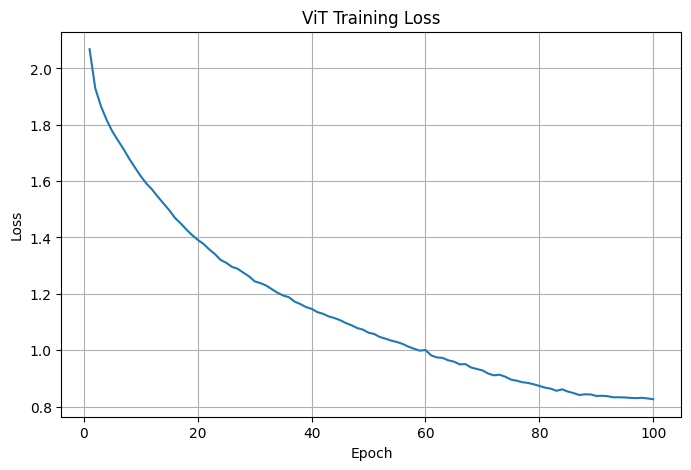

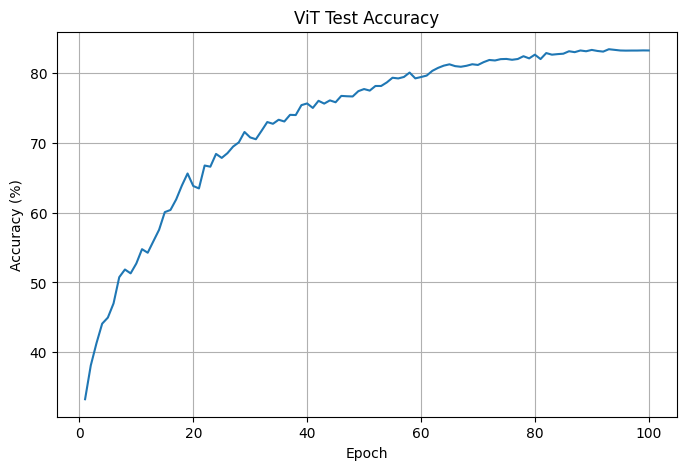

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import matplotlib.pyplot as plt

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader


# ======================
# Device
# ======================
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print(device)


# ======================
# Transform
# ======================
transform_train = transforms.Compose([

    transforms.Resize((96, 96)),

    transforms.RandomCrop(
        96,
        padding=16
    ),

    transforms.RandomHorizontalFlip(),

    transforms.RandAugment(
        num_ops=2,
        magnitude=9
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010)
    ),

    transforms.RandomErasing(
        p=0.25
    )
])

transform_test = transforms.Compose([

    transforms.Resize((96, 96)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010)
    )
])


# ======================
# Dataset
# ======================
trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=False,
    transform=transform_train
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=False,
    transform=transform_test
)

trainloader = DataLoader(
    trainset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

testloader = DataLoader(
    testset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


# ======================
# ViT
# ======================
model = timm.create_model(
    'vit_tiny_patch16_224',
    pretrained=False,
    num_classes=10,
    img_size=96
)

model = model.to(device)


# ======================
# Loss
# ======================
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=5e-4,
    weight_decay=0.05
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=100
)

scaler = torch.cuda.amp.GradScaler()


# ======================
# Record
# ======================
best_acc = 0

train_losses = []

test_accs = []


# ======================
# Train
# ======================
for epoch in range(100):

    model.train()

    running_loss = 0

    for images, labels in trainloader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

    scheduler.step()

    # ======================
    # Evaluate
    # ======================
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in testloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    acc = 100. * correct / total

    epoch_loss = running_loss / len(trainloader)

    train_losses.append(epoch_loss)

    test_accs.append(acc)

    print(
        f'Epoch [{epoch+1}/100] '
        f'Loss: {epoch_loss:.4f} '
        f'Acc: {acc:.2f}%'
    )

    if acc > best_acc:

        best_acc = acc

        torch.save(
            model.state_dict(),
            'best_vit.pth'
        )

        print('Model Saved')


print(f'Best Accuracy: {best_acc:.2f}%')


# ======================
# Plot
# ======================
epochs = range(1, 101)

plt.figure(figsize=(8,5))

plt.plot(epochs, train_losses)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ViT Training Loss')

plt.grid()

plt.show()


plt.figure(figsize=(8,5))

plt.plot(epochs, test_accs)

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('ViT Test Accuracy')

plt.grid()

plt.show()

CNN

cuda


C:\Users\hzghz\AppData\Local\Temp\ipykernel_28004\3898285159.py:130: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
C:\Users\hzghz\AppData\Local\Temp\ipykernel_28004\3898285159.py:159: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [1/100] Loss: 1.7935 Acc: 57.63%
Model Saved
Epoch [2/100] Loss: 1.4770 Acc: 63.48%
Model Saved
Epoch [3/100] Loss: 1.3319 Acc: 60.05%
Epoch [4/100] Loss: 1.2324 Acc: 70.61%
Model Saved
Epoch [5/100] Loss: 1.1657 Acc: 78.66%
Model Saved
Epoch [6/100] Loss: 1.1121 Acc: 77.52%
Epoch [7/100] Loss: 1.0738 Acc: 79.48%
Model Saved
Epoch [8/100] Loss: 1.0425 Acc: 81.34%
Model Saved
Epoch [9/100] Loss: 1.0136 Acc: 83.96%
Model Saved
Epoch [10/100] Loss: 0.9899 Acc: 82.91%
Epoch [11/100] Loss: 0.9666 Acc: 84.23%
Model Saved
Epoch [12/100] Loss: 0.9482 Acc: 83.33%
Epoch [13/100] Loss: 0.9320 Acc: 85.01%
Model Saved
Epoch [14/100] Loss: 0.9126 Acc: 85.95%
Model Saved
Epoch [15/100] Loss: 0.8986 Acc: 86.42%
Model Saved
Epoch [16/100] Loss: 0.8860 Acc: 86.45%
Model Saved
Epoch [17/100] Loss: 0.8736 Acc: 86.13%
Epoch [18/100] Loss: 0.8688 Acc: 86.33%
Epoch [19/100] Loss: 0.8497 Acc: 87.85%
Model Saved
Epoch [20/100] Loss: 0.8440 Acc: 88.49%
Model Saved
Epoch [21/100] Loss: 0.8289 Acc: 86.16%
E

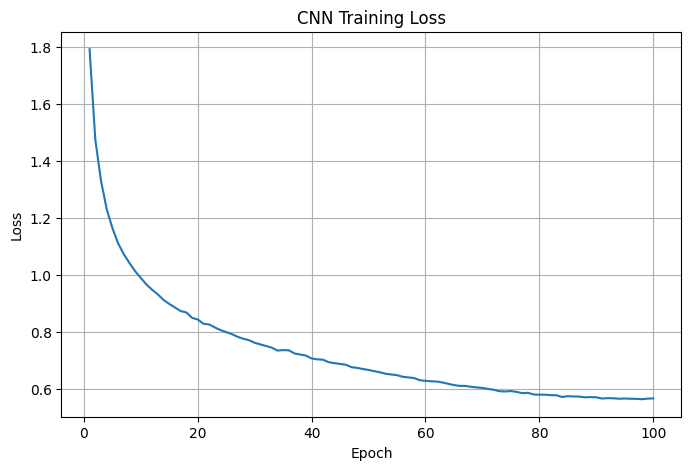

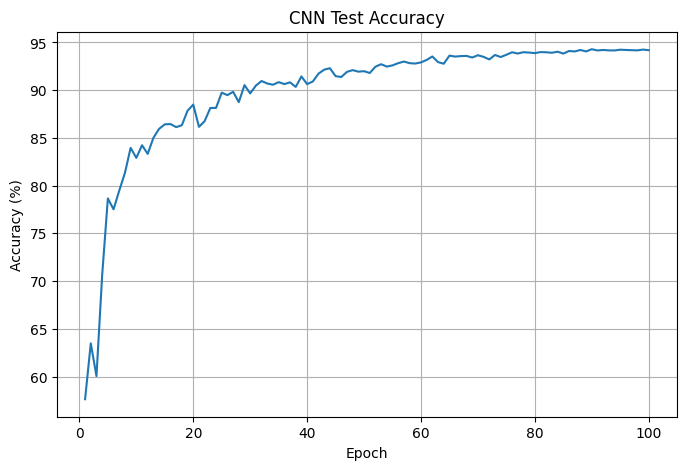

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

import torchvision
import torchvision.transforms as transforms

from torchvision.models import resnet18

from torch.utils.data import DataLoader


# ======================
# Device
# ======================
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print(device)


# ======================
# Transform
# ======================
transform_train = transforms.Compose([

    transforms.Resize((96, 96)),

    transforms.RandomCrop(
        96,
        padding=16
    ),

    transforms.RandomHorizontalFlip(),

    transforms.RandAugment(
        num_ops=2,
        magnitude=9
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010)
    ),

    transforms.RandomErasing(
        p=0.25
    )
])

transform_test = transforms.Compose([

    transforms.Resize((96, 96)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010)
    )
])


# ======================
# Dataset
# ======================
trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=False,
    transform=transform_train
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=False,
    transform=transform_test
)

trainloader = DataLoader(
    trainset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

testloader = DataLoader(
    testset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


# ======================
# CNN
# ======================
model = resnet18(
    num_classes=10
)

model = model.to(device)


# ======================
# Loss
# ======================
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=5e-4,
    weight_decay=0.05
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=100
)

scaler = torch.cuda.amp.GradScaler()


# ======================
# Record
# ======================
best_acc = 0

train_losses = []

test_accs = []


# ======================
# Train
# ======================
for epoch in range(100):

    model.train()

    running_loss = 0

    for images, labels in trainloader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

    scheduler.step()

    # ======================
    # Evaluate
    # ======================
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in testloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    acc = 100. * correct / total

    epoch_loss = running_loss / len(trainloader)

    train_losses.append(epoch_loss)

    test_accs.append(acc)

    print(
        f'Epoch [{epoch+1}/100] '
        f'Loss: {epoch_loss:.4f} '
        f'Acc: {acc:.2f}%'
    )

    if acc > best_acc:

        best_acc = acc

        torch.save(
            model.state_dict(),
            'best_resnet18.pth'
        )

        print('Model Saved')


print(f'Best Accuracy: {best_acc:.2f}%')


# ======================
# Plot
# ======================
epochs = range(1, 101)

plt.figure(figsize=(8,5))

plt.plot(epochs, train_losses)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Training Loss')

plt.grid()

plt.show()


plt.figure(figsize=(8,5))

plt.plot(epochs, test_accs)

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('CNN Test Accuracy')

plt.grid()

plt.show()